# Breast Cancer Wisconsin Decision Tree Analysis

This notebook loads the Breast Cancer Wisconsin dataset, trains Decision Tree classifiers with and without regularization, compares performance, and performs hyperparameter tuning with Grid Search, Randomized Search, and Optuna.

1. Load Dataset
        ↓
2. Explore Dataset
        ↓
3. Feature Selection / Feature Importance
        ↓
4. Split Training and Testing Data
        ↓
5. Train Basic Decision Tree
        ↓
6. Check Overfitting & underfitting
        ↓
7. Apply Regularization Parameters
        ↓
8. Compare Underfitting vs Overfitting
        ↓
9. Optimize Parameters
       - Grid Search
       - Random Search
       - Optuna
        ↓
10. Evaluate Models
       - Accuracy
       - Confusion Matrix
       - Classification Report
       - Cross Validation
        ↓
11. Visualize Decision Tree
        ↓
12. Visualize Decision Boundary

## 1. Import libraries

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA
import optuna

sns.set(style='whitegrid')


## 2. Load data, inspect balance, and select top features

Dataset shape: (569, 30)
Training samples: 426
Testing samples: 143

Class distribution:
target
1    0.627417
0    0.372583
Name: proportion, dtype: float64

Top 10 feature scores:
worst concave points    736.818364
mean concave points     675.650028
worst perimeter         661.444639
worst radius            634.139063
mean perimeter          530.656609
worst area              499.119290
mean radius             491.371838
mean area               441.363153
mean concavity          389.916976
worst concavity         339.345752
dtype: float64

Selected features:
['mean radius', 'mean perimeter', 'mean area', 'mean concavity', 'mean concave points', 'worst radius', 'worst perimeter', 'worst area', 'worst concavity', 'worst concave points']


C:\Users\User\AppData\Local\Temp\ipykernel_6904\2702482076.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_scores.head(10).values, y=feature_scores.head(10).index, palette='viridis')


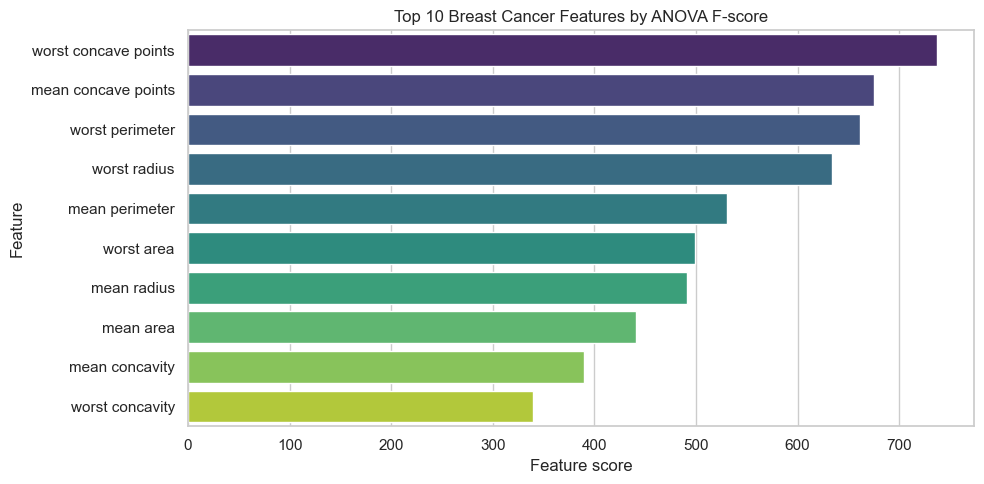


Using 10 selected features for model training.


In [72]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

print('Dataset shape:', X.shape)
print('Training samples:', X_train.shape[0])
print('Testing samples:', X_test.shape[0])

from sklearn.feature_selection import SelectKBest, f_classif

print('\nClass distribution:')
print(y.value_counts(normalize=True))

selector = SelectKBest(score_func=f_classif, k=10)
selector.fit(X_train, y_train)
selected_features = X.columns[selector.get_support()]
feature_scores = pd.Series(selector.scores_, index=X.columns).sort_values(ascending=False)

print('\nTop 10 feature scores:')
print(feature_scores.head(10))
print('\nSelected features:')
print(list(selected_features))

plt.figure(figsize=(10, 5))
sns.barplot(x=feature_scores.head(10).values, y=feature_scores.head(10).index, palette='viridis')
plt.title('Top 10 Breast Cancer Features by ANOVA F-score')
plt.xlabel('Feature score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

X_train = X_train[selected_features]
X_test = X_test[selected_features]
print(f'\nUsing {len(selected_features)} selected features for model training.')

## 3. Define helper functions

In [73]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name='Model'):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    cm = confusion_matrix(y_test, test_pred)
    cr = classification_report(y_test, test_pred, target_names=['malignant', 'benign'])
    print(f'=== {model_name} ===')
    print(f'Training accuracy: {train_acc:.4f}')
    print(f'Testing accuracy:  {test_acc:.4f}')
    print('Confusion matrix:')
    print(cm)
    print('Classification report:')
    print(cr)
    return {
        'train_accuracy': train_acc,
        'test_accuracy': test_acc,
        'confusion_matrix': cm,
        'classification_report': cr,
        'depth': model.get_depth(),
        'n_leaves': model.get_n_leaves(),
    }

def plot_tree_model(model, feature_names, class_names, title='Decision Tree'):
    plt.figure(figsize=(18, 10))
    plot_tree(
        model,
        feature_names=feature_names,
        class_names=class_names,
        filled=True,
        rounded=True,
        proportion=True,
        impurity=False,
        fontsize=10,
    )
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_decision_boundary(model, X, y, title='Decision Boundary'):
    pca = PCA(n_components=2)
    X2 = pca.fit_transform(X)
    x_min, x_max = X2[:, 0].min() - 1, X2[:, 0].max() + 1
    y_min, y_max = X2[:, 1].min() - 1, X2[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 250), np.linspace(y_min, y_max, 250))
    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_original = pca.inverse_transform(grid)
    Z = model.predict(grid_original).reshape(xx.shape)
    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, alpha=0.25, cmap='coolwarm')
    sns.scatterplot(x=X2[:, 0], y=X2[:, 1], hue=y.map({0: 'malignant', 1: 'benign'}),
                    palette='coolwarm', edgecolor='k')
    plt.title(title)
    plt.xlabel('PCA component 1')
    plt.ylabel('PCA component 2')
    plt.tight_layout()
    plt.show()

## 4. Train unregularized and regularized decision trees

In [74]:
unregularized_dt = DecisionTreeClassifier(random_state=42)
unregularized_dt.fit(X_train, y_train)

regularized_dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=4,
    min_samples_leaf=5,
    min_samples_split=10,
)
regularized_dt.fit(X_train, y_train)

print('Unregularized and regularized models trained.')

Unregularized and regularized models trained.


## 5. Evaluate both models

In [75]:
results_unreg = evaluate_model(unregularized_dt, X_train, y_train, X_test, y_test, model_name='Unregularized DT')
results_reg = evaluate_model(regularized_dt, X_train, y_train, X_test, y_test, model_name='Regularized DT')

=== Unregularized DT ===
Training accuracy: 1.0000
Testing accuracy:  0.9301
Confusion matrix:
[[48  5]
 [ 5 85]]
Classification report:
              precision    recall  f1-score   support

   malignant       0.91      0.91      0.91        53
      benign       0.94      0.94      0.94        90

    accuracy                           0.93       143
   macro avg       0.93      0.93      0.93       143
weighted avg       0.93      0.93      0.93       143

=== Regularized DT ===
Training accuracy: 0.9671
Testing accuracy:  0.9301
Confusion matrix:
[[48  5]
 [ 5 85]]
Classification report:
              precision    recall  f1-score   support

   malignant       0.91      0.91      0.91        53
      benign       0.94      0.94      0.94        90

    accuracy                           0.93       143
   macro avg       0.93      0.93      0.93       143
weighted avg       0.93      0.93      0.93       143



In [76]:
for name, model in [('Unregularized DT', unregularized_dt), ('Regularized DT', regularized_dt)]:
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    gap = train_acc - test_acc
    print(f"{name}: train={train_acc:.4f}, test={test_acc:.4f}, gap={gap:.4f}")
    if gap > 0.05:
        print(f"  - {name} shows signs of overfitting because train accuracy is significantly higher than test accuracy.")
    elif train_acc < 0.80 and test_acc < 0.80:
        print(f"  - {name} may be underfitting because both train and test accuracy are low.")
    else:
        print(f"  - {name} has a reasonable fit." )
    print()


Unregularized DT: train=1.0000, test=0.9301, gap=0.0699
  - Unregularized DT shows signs of overfitting because train accuracy is significantly higher than test accuracy.

Regularized DT: train=0.9671, test=0.9301, gap=0.0371
  - Regularized DT has a reasonable fit.



results_unreg = evaluate_model(unregularized_dt, X_train, y_train, X_test, y_test, model_name='Unregularized DT')
results_reg = evaluate_model(regularized_dt, X_train, y_train, X_test, y_test, model_name='Regularized DT')

print('\nUnregularized Decision Tree text:')
print(export_text(unregularized_dt, feature_names=list(selected_features)))
print('\nRegularized Decision Tree text:')
print(export_text(regularized_dt, feature_names=list(selected_features)))


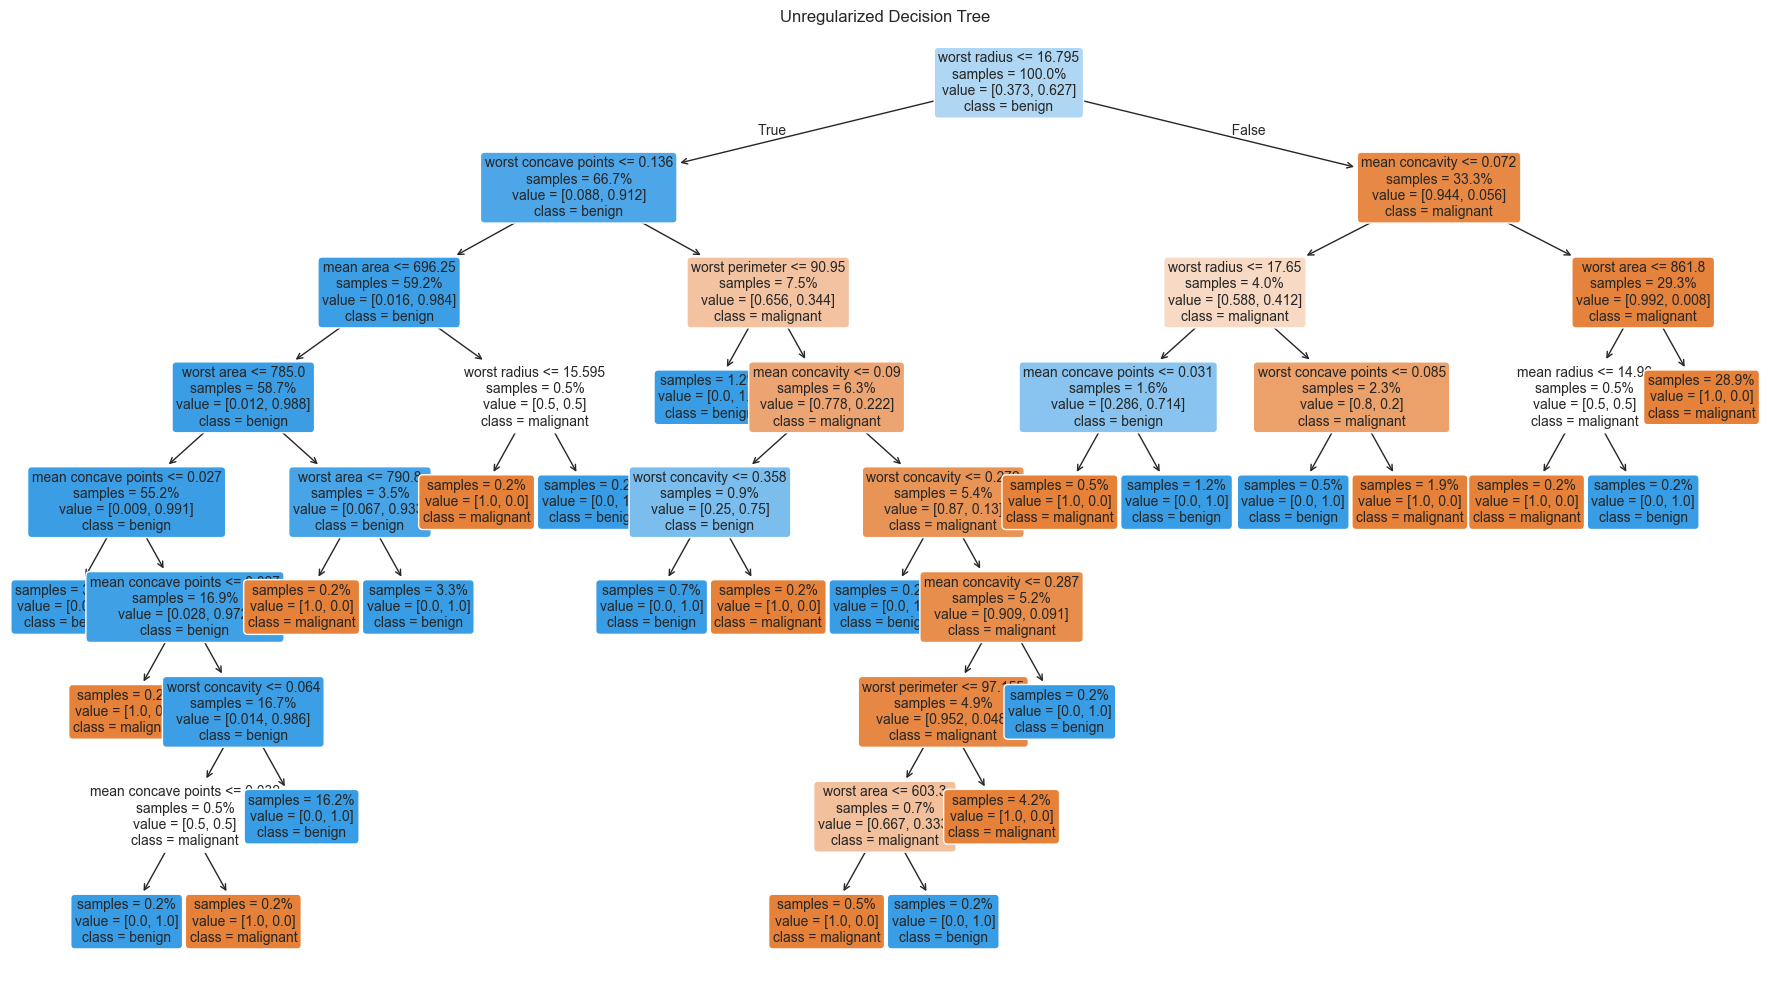

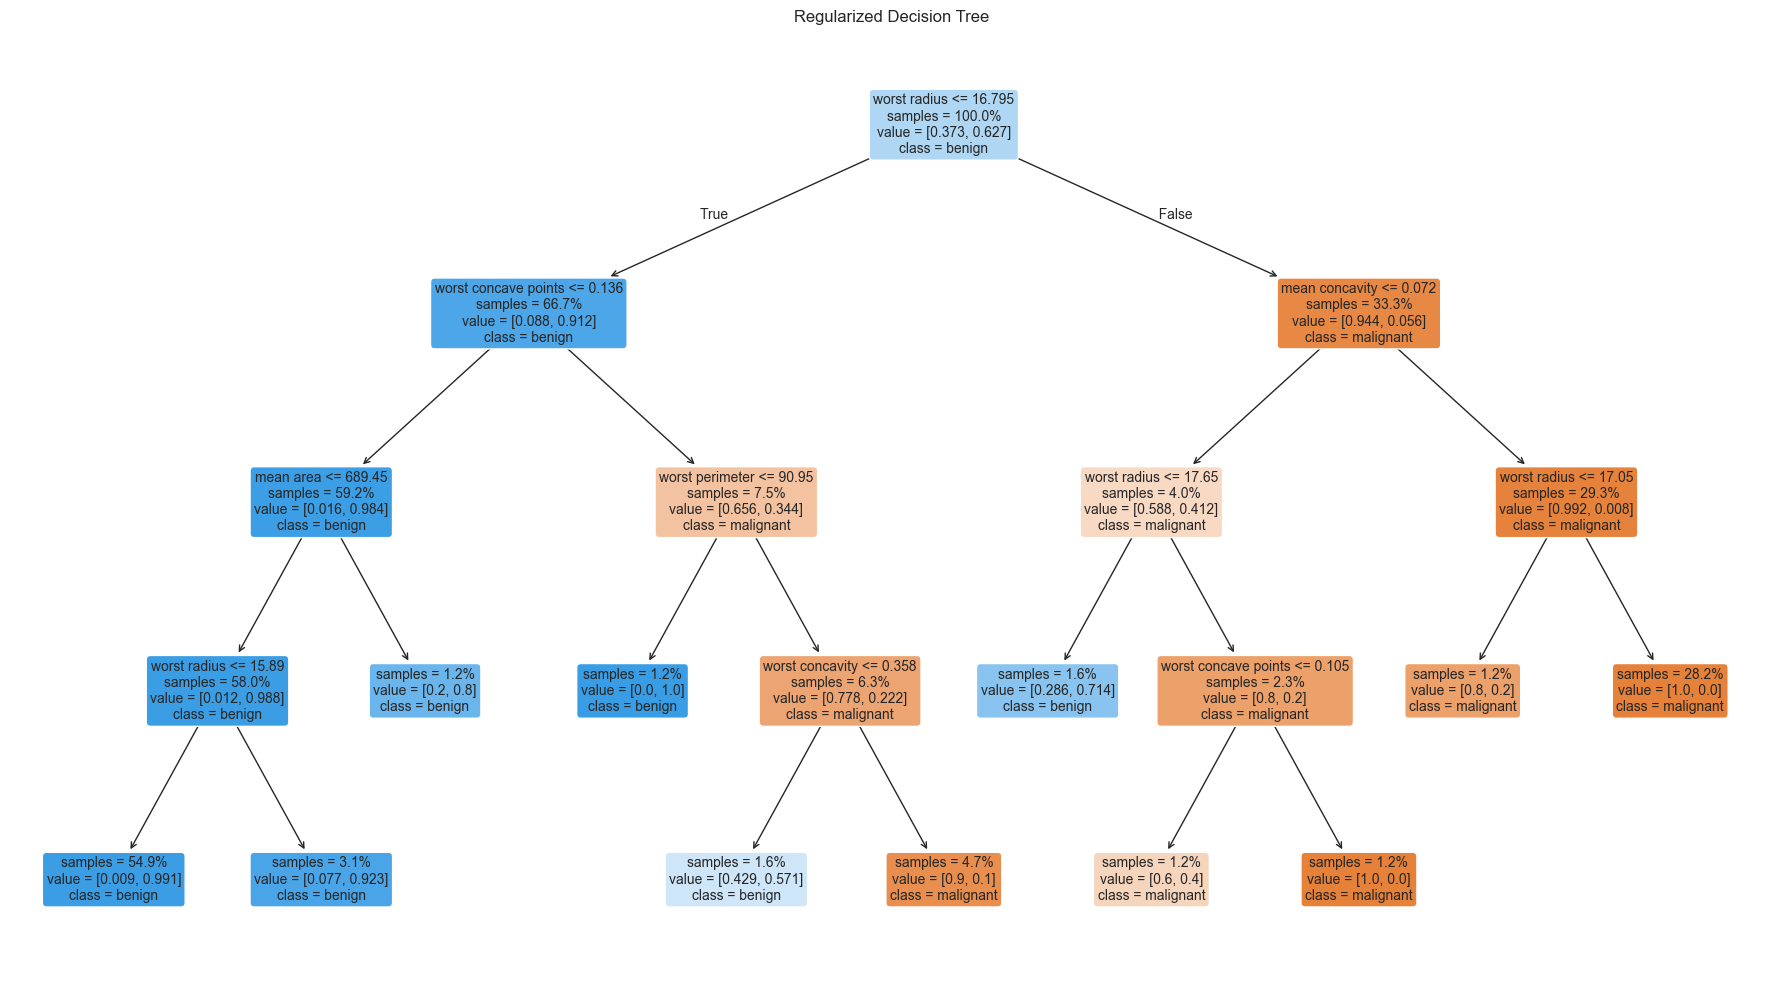

In [77]:
plot_tree_model(unregularized_dt, selected_features, data.target_names, title='Unregularized Decision Tree')
plot_tree_model(regularized_dt, selected_features, data.target_names, title='Regularized Decision Tree')


## 7. Compare decision boundaries using top two selected features
The boundary plot is based on the two most important selected features. To make regularization differences more visible, we train simple decision trees on those features and compare their decision regions directly.

## 8. Hyperparameter tuning with Grid Search, Randomized Search, and Optuna

In [78]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 3, 4, 5, 6],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
}
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)
grid_dt = grid_search.best_estimator_
print('Grid Search best params:', grid_search.best_params_)
print(f'Grid Search best CV accuracy: {grid_search.best_score_:.4f}')

param_dist = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 3, 4, 5, 6, 7],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 5, 8],
    'max_features': [None, 'sqrt', 'log2'],
}
random_search = RandomizedSearchCV(DecisionTreeClassifier(random_state=42), param_distributions=param_dist, n_iter=15, cv=5, scoring='accuracy', n_jobs=-1, random_state=42)
random_search.fit(X_train, y_train)
random_dt = random_search.best_estimator_
print('Random Search best params:', random_search.best_params_)
print(f'Random Search best CV accuracy: {random_search.best_score_:.4f}')

def optuna_objective(trial):
    params = {
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', [None, 'sqrt', 'log2']),
    }
    model = DecisionTreeClassifier(random_state=42, **params)
    score = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
    return score.mean()

study = optuna.create_study(direction='maximize')
study.optimize(optuna_objective, n_trials=30)
optuna_dt = DecisionTreeClassifier(random_state=42, **study.best_trial.params)
optuna_dt.fit(X_train, y_train)
print('Optuna best params:', study.best_trial.params)
print(f'Optuna best CV accuracy: {study.best_trial.value:.4f}')

[I 2026-08-06 01:02:06,472] A new study created in memory with name: no-name-a373be7e-4284-4a60-bea2-58c4ae87a872
[I 2026-08-06 01:02:06,488] Trial 0 finished with value: 0.9389329685362517 and parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 4, 'min_samples_leaf': 7, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.9389329685362517.
[I 2026-08-06 01:02:06,513] Trial 1 finished with value: 0.9412859097127223 and parameters: {'criterion': 'gini', 'max_depth': 8, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.9412859097127223.
[I 2026-08-06 01:02:06,528] Trial 2 finished with value: 0.93890560875513 and parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 17, 'min_samples_leaf': 8, 'max_features': None}. Best is trial 1 with value: 0.9412859097127223.


Grid Search best params: {'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 2, 'min_samples_split': 10}
Grid Search best CV accuracy: 0.9530
Random Search best params: {'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 3, 'criterion': 'gini'}
Random Search best CV accuracy: 0.9460


[I 2026-08-06 01:02:06,544] Trial 3 finished with value: 0.9389329685362517 and parameters: {'criterion': 'entropy', 'max_depth': 8, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.9412859097127223.
[I 2026-08-06 01:02:06,560] Trial 4 finished with value: 0.9272229822161423 and parameters: {'criterion': 'entropy', 'max_depth': 8, 'min_samples_split': 12, 'min_samples_leaf': 4, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.9412859097127223.
[I 2026-08-06 01:02:06,577] Trial 5 finished with value: 0.927250341997264 and parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 11, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.9412859097127223.
[I 2026-08-06 01:02:06,592] Trial 6 finished with value: 0.9131326949384405 and parameters: {'criterion': 'entropy', 'max_depth': 9, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 1 with value: 0.94128

Optuna best params: {'criterion': 'gini', 'max_depth': 7, 'min_samples_split': 15, 'min_samples_leaf': 10, 'max_features': 'sqrt'}
Optuna best CV accuracy: 0.9507


## 9. Compare all models

In [79]:
models = {
    'Unregularized DT': unregularized_dt,
    'Regularized DT': regularized_dt,
    'Grid Search DT': grid_dt,
    'Random Search DT': random_dt,
    'Optuna DT': optuna_dt,
}
comparison_rows = []
for name, model in models.items():
    result = evaluate_model(model, X_train, y_train, X_test, y_test, model_name=name)
    comparison_rows.append({
        'Model': name,
        'Train Accuracy': result['train_accuracy'],
        'Test Accuracy': result['test_accuracy'],
        'Depth': result['depth'],
        'Leaves': result['n_leaves'],
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
comparison_df

=== Unregularized DT ===
Training accuracy: 1.0000
Testing accuracy:  0.9301
Confusion matrix:
[[48  5]
 [ 5 85]]
Classification report:
              precision    recall  f1-score   support

   malignant       0.91      0.91      0.91        53
      benign       0.94      0.94      0.94        90

    accuracy                           0.93       143
   macro avg       0.93      0.93      0.93       143
weighted avg       0.93      0.93      0.93       143

=== Regularized DT ===
Training accuracy: 0.9671
Testing accuracy:  0.9301
Confusion matrix:
[[48  5]
 [ 5 85]]
Classification report:
              precision    recall  f1-score   support

   malignant       0.91      0.91      0.91        53
      benign       0.94      0.94      0.94        90

    accuracy                           0.93       143
   macro avg       0.93      0.93      0.93       143
weighted avg       0.93      0.93      0.93       143

=== Grid Search DT ===
Training accuracy: 0.9812
Testing accuracy:  0.9301

,Model,Train Accuracy,Test Accuracy,Depth,Leaves
0,Optuna DT,0.957746,0.951049,5,10
1,Unregularized DT,1.000000,0.930070,8,24
2,Regularized DT,0.967136,0.930070,4,11
3,Grid Search DT,0.981221,0.930070,6,14
4,Random Search DT,0.964789,0.916084,3,8


## 10. Cross-validation stability comparison

In [80]:
cv_rows = []
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='accuracy', n_jobs=-1)
    cv_rows.append({
        'Model': name,
        'CV Mean Accuracy': scores.mean(),
        'CV Std Dev': scores.std(),
    })
cv_df = pd.DataFrame(cv_rows).sort_values('CV Mean Accuracy', ascending=False).reset_index(drop=True)
cv_df

,Model,CV Mean Accuracy,CV Std Dev
0,Grid Search DT,0.933240,0.020396
1,Regularized DT,0.927930,0.021818
2,Random Search DT,0.917358,0.023459
3,Unregularized DT,0.917342,0.024195
4,Optuna DT,0.913926,0.034748
